<p align="center">
  <img src="img/logoitqv1.png" width="270" style="margin-right: 20px;">
</p>
<br>

# Programa3.Outliers

## 0.1 DETECCIÓN DE OUTLIERS
<br>

<img src="img/python_logo.png" width="300">
<br>

*Ian Mijail Morales Patiño*

<br>
<a href="https://github.com/Ian-183/practica-machine-learning">https://github.com/Ian-183/practica-machine-learningb</a>

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.covariance import EllipticEnvelope
import matplotlib.pyplot as plt

In [2]:
# Carga de datos.
df = pd.read_csv("dataset/outliers.csv")
print(df)

            a         b
0    0.173850 -0.048393
1    0.226691  0.533060
2   -0.081954 -0.081948
3    0.552724  0.268602
4   -0.164316  0.189896
..        ...       ...
195 -5.114441  0.646251
196  5.631630  0.277174
197  1.552784  2.348984
198 -0.545507  1.530697
199  1.011772  4.813896

[200 rows x 2 columns]


### 1) EllipticEnvelope()

In [3]:
# Entrenamos un objeto de tipo EllipticEnvelope
algorithm = EllipticEnvelope(support_fraction=None, contamination=0.25,
                             random_state=42)
outlier_method = algorithm.fit(df)
# Aplicamos el metodo de deteccion de outliers entrenado sobre nuestro dataset
# (devuelve 1 = inlier, -1 = outlier)
df_outliers = outlier_method.predict(df)
print(df_outliers)

# Determinar la posicion de los outliers
pos_outliers = np.where(df_outliers == -1)[0]
print('\nOutliers en la posición: \n', pos_outliers)

# Determinar el numero de outliers
print('\nNúmero de outliers: \n', len(pos_outliers))

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1]

Outliers en la posición: 
 [104 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 167
 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185
 186 187 188 189 190 191 192 193 194 195 196 197 198 199]

Número de outliers: 
 50


In [4]:
# Definimos una funcion que, dado un determinado "df" y un "algorithm",
# devuelva la matriz y la posicion de outliers
def find_outliers(df, algorithm):
    outlier_method = algorithm.fit(df)
    # Aplicamos el metodo de deteccion de outliers entrenado sobre nuestro dataset
    df_outliers = outlier_method.predict(df)
    print(df_outliers)
    # Determinamos la posicion de los outliers
    pos_outliers = np.where(df_outliers == -1)[0]
    print('\nOutliers en la posición :\n', pos_outliers)
    # Determinamos el numero de outliers
    print('\nNúmero de outliers: \n', len(pos_outliers))
    return df_outliers, pos_outliers

### 2) Otros métodos similares

In [5]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

IF = IsolationForest(max_samples='auto', random_state=42)
# One-Class SVM: nu controla la fraccion aproximada de outliers
OC_SVM = OneClassSVM(kernel='rbf', gamma='scale', nu=0.25)
# LOF con novelty=True para poder usar fit + predict (como find_outliers)
LOF = LocalOutlierFactor(n_neighbors=20, contamination=0.25, novelty=True)

df_outliers, pos_outliers = find_outliers(df, IF)
print(len(pos_outliers))

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1  1 -1]

Outliers en la posición :
 [150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 167 168
 169 170 171 172 173 174 175 176 178 180 181 182 183 184 185 186 187 188
 189 190 191 192 193 194 195 196 197 199]

Número de outliers: 
 46
46


In [6]:
df.head(10)

,a,b
0,0.173850,-0.048393
1,0.226691,0.533060
2,-0.081954,-0.081948
3,0.552724,0.268602
4,-0.164316,0.189896
5,-0.162196,-0.163005
6,0.084687,-0.669648
7,-0.603721,-0.196801
8,-0.354491,0.109987
9,-0.317808,-0.494306


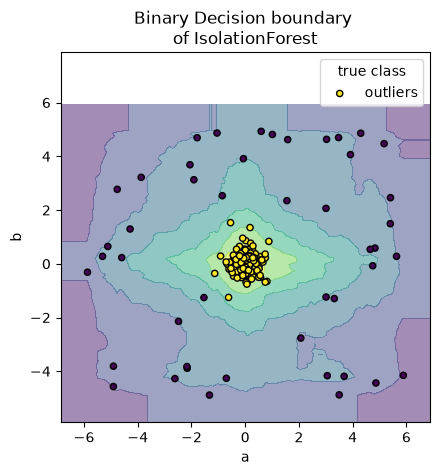

In [7]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

disp = DecisionBoundaryDisplay.from_estimator(
    IF,
    df,
    response_method="decision_function",
    alpha=0.5,
)
disp.ax_.scatter(df.a, df.b, c=df_outliers, s=20, edgecolor="k")
disp.ax_.set_title("Binary Decision boundary \nof IsolationForest")
plt.axis("square")
plt.legend(labels=["outliers", "inliers"], title="true class")
plt.show()

In [8]:
# Eliminamos los outliers
new_df = df[df_outliers == 1]
print(new_df)

            a         b
0    0.173850 -0.048393
1    0.226691  0.533060
2   -0.081954 -0.081948
3    0.552724  0.268602
4   -0.164316  0.189896
..        ...       ...
149  0.284502  0.220370
166  0.063028 -0.757780
177  0.881255  0.833688
179 -0.618654 -1.251294
198 -0.545507  1.530697

[154 rows x 2 columns]


### 3) Box plot

limite inferior:  -1.214019318673388
limite superior:  1.188833146096165
Posición de outliers:  [150 151 156 158 164 168 170 171 173 174 180 181 186 188 192 193 194 195
 152 153 154 157 159 160 162 163 165 167 169 172 175 176 178 182 183 184
 185 191 196 197]
Número de outliers:  40


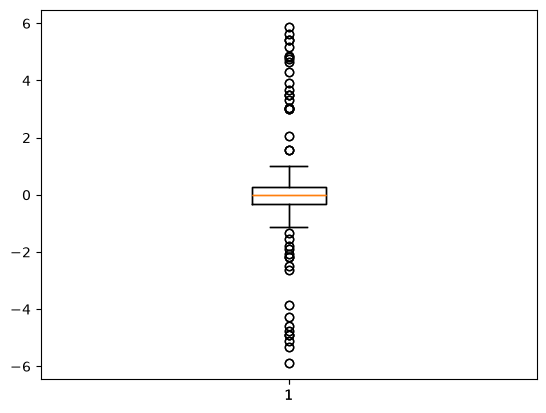

In [9]:
# Seleccionamos el atributo que vamos a medir
a = df['a']

# Seleccionamos los umbrales a partir de los cuales vamos a considerar outliers
Q1 = stats.scoreatpercentile(a, 25)
Q3 = stats.scoreatpercentile(a, 75)
RIC = Q3 - Q1
li = Q1 - 1.5 * RIC  # xmin
ls = Q3 + 1.5 * RIC  # xmax

# Observamos los limites inferior y superior
print('limite inferior: ', li)
print('limite superior: ', ls)

# Buscamos la posicion de los outliers
pos_i = np.where(a < li)[0]
pos_s = np.where(a > ls)[0]
pos_outliers = np.concatenate((pos_i, pos_s))
print('Posición de outliers: ', pos_outliers)
print('Número de outliers: ', len(pos_outliers))

# Dibujamos el diagrama de caja y bigotes
prop = plt.boxplot(a)
plt.boxplot(a)
plt.show()

In [10]:
# Definir una funcion que, dada una columna de un dataframe,
# devuelva la posicion de los outliers segun el metodo box plot
def find_limits_BP(variable):
    Q1 = stats.scoreatpercentile(variable, 25)
    Q3 = stats.scoreatpercentile(variable, 75)
    RIC = Q3 - Q1
    li = Q1 - 1.5 * RIC
    ls = Q3 + 1.5 * RIC
    pos_i = np.where(variable < li)[0]
    pos_s = np.where(variable > ls)[0]
    pos_outliers = np.concatenate((pos_i, pos_s))
    return pos_outliers

In [11]:
# Creamos un bucle for que estime los valores outliers de cada atributo
headers = df.columns  # nombre de los atributos del CSV
pos_outliers = []
for i in range(len(headers)):
    variable = df[headers[i]]  # Atributo 'x'
    pos_out = np.expand_dims(find_limits_BP(variable), axis=1)  # Llamamos a la funcion
    pos_outliers.append(pos_out)  # Lo anadimos en una lista

# Concatenamos todas las posiciones de outliers
po = np.vstack(pos_outliers)

# Vemos las posiciones de todos los outliers
pos_out = np.unique(po)
print('Posiciones de outliers: ', pos_out)

# Observamos el numero de outliers
print('Numero de outliers: ', len(pos_out))

Posiciones de outliers:  [104 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 167
 168 169 170 171 172 173 174 175 176 178 179 180 181 182 183 184 185 186
 187 188 189 190 191 192 193 194 195 196 197 198 199]
Numero de outliers:  49
